# 词嵌入

## 1. Skip-gram

从零开始实现一个简单的Skip-gram,语料库使用《爱丽丝梦游仙境》(Alice's Adventures in Wonderland) 的开篇片段。

### 第一步：加载与清洗数据 (Data Preprocessing)

我们要写一个清洗函数。这在 NLP 中叫做 Tokenization (分词) 和 Normalization (标准化)。

In [1]:
import torch
import re
import torch.optim as optim
from torch import nn
from collections import Counter

# 1. 定义语料库
raw_text = """
Alice was beginning to get very tired of sitting by her sister on the bank, and of having nothing to do: once or twice she had peeped into the book her sister was reading, but it had no pictures or conversations in it, 'and what is the use of a book,' thought Alice 'without pictures or conversation?'
So she was considering in her own mind (as well as she could, for the hot day made her feel very sleepy and stupid), whether the pleasure of making a daisy-chain would be worth the trouble of getting up and picking the daisies, when suddenly a White Rabbit with pink eyes ran close by her.
There was nothing so very remarkable in that; nor did Alice think it so very much out of the way to hear the Rabbit say to itself, 'Oh dear! Oh dear! I shall be too late!' (when she thought it over afterwards, it occurred to her that she ought to have wondered at this, but at the time it all seemed quite natural); but when the Rabbit actually took a watch out of its waistcoat-pocket, and looked at it, and then hurried on, Alice started to her feet, for it flashed across her mind that she had never before seen a rabbit with either a waistcoat-pocket, or a watch to take out of it, and burning with curiosity, she ran across the field after it, and fortunately was just in time to see it pop down a large rabbit-hole under the hedge.
"""

# 2. 定义停用词 (Stopwords)
# 在实际工程中，我们通常使用 NLTK 或 spaCy 库的停用词表
# 这里我们手动定义一些高频无意义词
stop_words = set(['the', 'of', 'and', 'a', 'to', 'in', 'was', 'it', 
                  'that', 'she', 'her', 'as', 'for', 'with', 'on', 'at',
                  'by', 'but', 'is', 'had', 'not', 'be', 'so', 'very', 'or'])

def preprocess_text(text):
    # 3. 文本清洗
    # 将文本转换为小写
    text = text.lower()
    # 去除标点符号
    text = re.sub(r'[^\w\s]', '', text)
    # 分词
    words = text.split()
    # 去除停用词
    words = [word for word in words if word not in stop_words]
    return words

processed_words = preprocess_text(raw_text)
print("Processed Words: \n", processed_words)

Processed Words: 
 ['alice', 'beginning', 'get', 'tired', 'sitting', 'sister', 'bank', 'having', 'nothing', 'do', 'once', 'twice', 'peeped', 'into', 'book', 'sister', 'reading', 'no', 'pictures', 'conversations', 'what', 'use', 'book', 'thought', 'alice', 'without', 'pictures', 'conversation', 'considering', 'own', 'mind', 'well', 'could', 'hot', 'day', 'made', 'feel', 'sleepy', 'stupid', 'whether', 'pleasure', 'making', 'daisychain', 'would', 'worth', 'trouble', 'getting', 'up', 'picking', 'daisies', 'when', 'suddenly', 'white', 'rabbit', 'pink', 'eyes', 'ran', 'close', 'there', 'nothing', 'remarkable', 'nor', 'did', 'alice', 'think', 'much', 'out', 'way', 'hear', 'rabbit', 'say', 'itself', 'oh', 'dear', 'oh', 'dear', 'i', 'shall', 'too', 'late', 'when', 'thought', 'over', 'afterwards', 'occurred', 'ought', 'have', 'wondered', 'this', 'time', 'all', 'seemed', 'quite', 'natural', 'when', 'rabbit', 'actually', 'took', 'watch', 'out', 'its', 'waistcoatpocket', 'looked', 'then', 'hurried'

In [2]:
# 构建词表
vocab = set(processed_words)
word_to_idx = {word: i for i, word in enumerate(vocab)}
idx_to_word = {i: word for i, word in enumerate(vocab)}
vocab_size = len(vocab)

print(f"原始单词数: {len(raw_text.split())}")
print(f"清洗后单词数: {len(processed_words)}")
print(f"词表大小 (去重): {vocab_size}")
print("前10个有效单词:", processed_words[:10])

原始单词数: 254
清洗后单词数: 136
词表大小 (去重): 113
前10个有效单词: ['alice', 'beginning', 'get', 'tired', 'sitting', 'sister', 'bank', 'having', 'nothing', 'do']


### 第二步：生成训练对 (Training Pairs)

这是 Skip-gram 的灵魂。我们要生成 (中心词, 上下文词) 的配对。

我们假设窗口大小为2。

In [3]:
window_size = 2
skipgram_pairs = []

for i in range(len(processed_words)):
    center_word = processed_words[i]
    
    # 左右各看 window_size 个词
    for j in range(max(0, i - window_size), min(len(processed_words), i + window_size + 1)):
        if i != j:
            context_word = processed_words[j]
            skipgram_pairs.append((word_to_idx[center_word], word_to_idx[context_word]))

print(f"生成的训练样本对数量: {len(skipgram_pairs)}")

生成的训练样本对数量: 538


### 第三步：定义模型 (Model Definition)

模型结构非常简单，只有两层：

1. Embedding 层：这就是我们要训练的“词向量表”。它把一个 ID 变成一个向量。
2. Linear 层（输出层）：把向量转换回词表大小的概率分布，用来预测下一个词。

In [4]:
class SkipGramModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim):
        super(SkipGramModel, self).__init__()
        # 1. 词向量层：这是我们要训练的核心
        # 它就像一个查找表，输入 ID，输出一个向量
        self.embeddings = nn.Embedding(vocab_size, embedding_dim)
        
        # 2. 预测层：将词向量映射回词表大小，用于预测上下文词
        self.output_layer = nn.Linear(embedding_dim, vocab_size)

    def forward(self, inputs):
        # inputs: 中心词的 ID 列表
        
        # 步骤 1: 查表，得到中心词的向量
        # shape: (batch_size, embedding_dim)
        embeds = self.embeddings(inputs)
        
        # 步骤 2: 计算预测得分
        # shape: (batch_size, vocab_size)
        scores = self.output_layer(embeds)
        
        return scores

# 初始化模型超参数
embedding_dim = 10  # 词向量的维度
learning_rate = 0.005 # 学习率
epochs = 3000

# 初始化模型、损失函数和优化器
model = SkipGramModel(vocab_size, embedding_dim)
criterion = nn.CrossEntropyLoss() # 分类任务的标准损失函数
optimizer = optim.Adam(model.parameters(), lr=learning_rate) # 优化器

print(model)

SkipGramModel(
  (embeddings): Embedding(113, 10)
  (output_layer): Linear(in_features=10, out_features=113, bias=True)
)


### 第四步：开始训练

我们要把准备好的数据喂给模型，不断进行“预测 -> 算错多少 -> 修改参数”的循环。

In [5]:
# 准备数据 (转为 Tensor)
# zip(*list) 是一个 Python 小技巧，把 [(a,b), (c,d)] 变成 (a,c) 和 (b,d)
inputs_data, targets_data = zip(*skipgram_pairs)
inputs = torch.tensor(inputs_data)  # 中心词 IDs
targets = torch.tensor(targets_data) # 上下文词 IDs

for epoch in range(epochs):
    # 1. 梯度清零 (PyTorch 标准动作)
    optimizer.zero_grad()
    
    # 2. 前向传播 (模型预测)
    output = model(inputs)
    
    # 3. 计算损失 (预测结果 vs 真实结果)
    loss = criterion(output, targets)
    
    # 4. 反向传播 (计算梯度)
    loss.backward()
    
    # 5. 更新参数
    optimizer.step()
    
    if (epoch + 1) % 200 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}')

Epoch [200/3000], Loss: 2.0814
Epoch [400/3000], Loss: 1.6787
Epoch [600/3000], Loss: 1.6369
Epoch [800/3000], Loss: 1.6260
Epoch [1000/3000], Loss: 1.6216
Epoch [1200/3000], Loss: 1.6193
Epoch [1400/3000], Loss: 1.6180
Epoch [1600/3000], Loss: 1.6172
Epoch [1800/3000], Loss: 1.6166
Epoch [2000/3000], Loss: 1.6162
Epoch [2200/3000], Loss: 1.6159
Epoch [2400/3000], Loss: 1.6157
Epoch [2600/3000], Loss: 1.6156
Epoch [2800/3000], Loss: 1.6154
Epoch [3000/3000], Loss: 1.6153


### 第五步：高级可视化 (Visualization with PCA)

这里有一个问题：我们的词向量现在是 10 维的，人类无法在纸上画出 10 维的图。

因此我们需要，降维 (Dimensionality Reduction)。我们使用 PCA（主成分分析）把 10 维压扁成 2 维，方便画图。

我们将重点展示词频最高的 20 个词，看看它们是如何分布的。

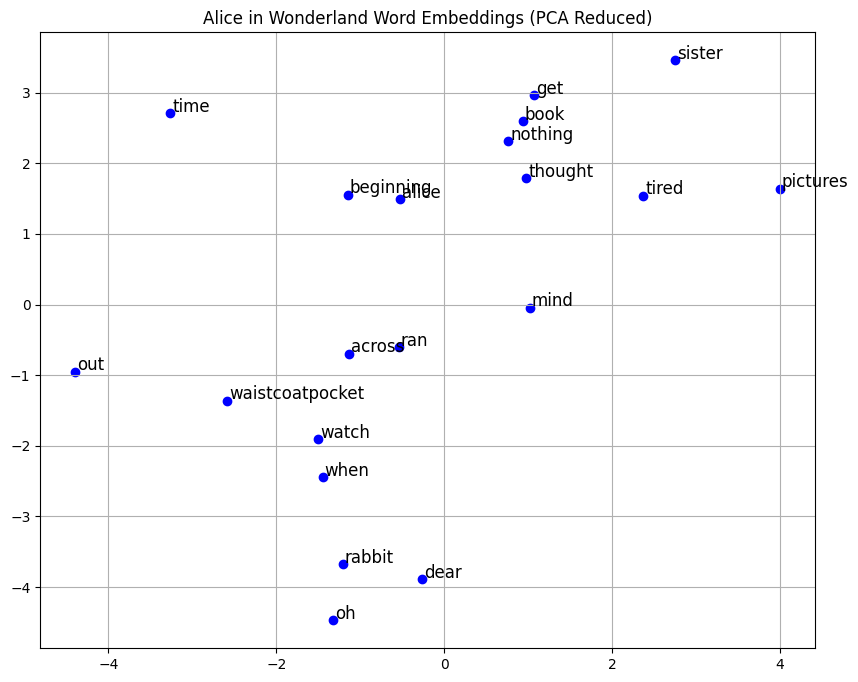

与 'alice' 最接近的词: [('just', 0.51261985), ('reading', 0.49784362), ('tired', 0.47144982)]
与 'rabbit' 最接近的词: [('never', 0.66640294), ('white', 0.5831611), ('late', 0.58141017)]


In [6]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA # 使用 sklearn 进行降维

# 1. 获取所有词向量
all_embeddings = model.embeddings.weight.detach().numpy()

# 2. 使用 PCA 将 10维 -> 2维
pca = PCA(n_components=2)
embeddings_2d = pca.fit_transform(all_embeddings)

# 3. 挑选出现频率最高的 20 个词来画图 (避免图太乱)
word_counts = Counter(processed_words)
top_words = [w for w, c in word_counts.most_common(20)]

plt.figure(figsize=(10, 8))

for word in top_words:
    idx = word_to_idx[word]
    x, y = embeddings_2d[idx]
    plt.scatter(x, y, color='blue')
    plt.text(x+0.02, y+0.02, word, fontsize=12)

plt.title("Alice in Wonderland Word Embeddings (PCA Reduced)")
plt.grid(True)
plt.show()

# 4. 余弦相似度查询函数
def find_similar_words(target_word, top_k=3):
    if target_word not in word_to_idx:
        return "Word not in vocabulary!"
    
    target_vec = all_embeddings[word_to_idx[target_word]]
    similarities = {}
    
    for word, idx in word_to_idx.items():
        if word == target_word: continue
        vec = all_embeddings[idx]
        # 计算余弦相似度
        sim = vec.dot(target_vec) / (np.linalg.norm(vec) * np.linalg.norm(target_vec))
        similarities[word] = sim
        
    # 排序
    sorted_words = sorted(similarities.items(), key=lambda x: x[1], reverse=True)
    return sorted_words[:top_k]

# 测试一下
print("与 'alice' 最接近的词:", find_similar_words('alice'))
print("与 'rabbit' 最接近的词:", find_similar_words('rabbit'))